## Re-Identification Datasets von SoccerNet 

In [ ]:
from SoccerNet.Downloader import SoccerNetDownloader
import os
from dotenv import load_dotenv

# .env laden
load_dotenv()

password = os.getenv("SOCCERNET_PASSWORD")

if password is None:
    raise ValueError("SOCCERNET_PASSWORD not found in environment variables")

# Speicherort für SoccerNet Daten
downloader = SoccerNetDownloader(LocalDirectory="/data/manser/soccernet")

# Passwort setzen
downloader.password = password

# Re-identification dataset herunterladen
downloader.downloadDataTask(
    task="reid",
    split=["train", "valid", "test", "challenge"]
)

# optional: neue Version
downloader.downloadDataTask(
    task="reid-2023",
    split=["train", "valid", "test", "challenge"]
)

Downloading /data/manser/soccernet/reid/train.zip...: : 12.1GiB [11:10, 18.1MiB/s]                           
Downloading /data/manser/soccernet/reid/valid.zip...: : 2.35GiB [05:46, 6.80MiB/s]                          
Downloading /data/manser/soccernet/reid/test.zip...: : 2.41GiB [06:29, 6.19MiB/s]                          
Downloading /data/manser/soccernet/reid/challenge.zip...: : 1.75GiB [02:59, 9.74MiB/s] 

In [1]:
from pathlib import Path
import json

base = Path("/data/manser/soccernet/reid")

print("Existiert:", base.exists())
print("\nTop-Level Inhalte:")
for p in sorted(base.iterdir()):
    print("-", p.name, "(dir)" if p.is_dir() else "(file)")

print("\nEin paar Dateien rekursiv:")
all_files = list(base.rglob("*"))
for p in all_files[:50]:
    print(p)

print(f"\nGesamtanzahl Eintraege: {len(all_files)}")

Existiert: True

Top-Level Inhalte:
- challenge.zip (file)
- test.zip (file)
- train.zip (file)
- valid.zip (file)

Ein paar Dateien rekursiv:
/data/manser/soccernet/reid/train.zip
/data/manser/soccernet/reid/valid.zip
/data/manser/soccernet/reid/challenge.zip
/data/manser/soccernet/reid/test.zip

Gesamtanzahl Eintraege: 4


Struktur:

reid/train/train/
    train_bbox_info.json
    version.json
    germany_bundesliga/
    france_ligue-1/
    spain_laliga/
    europe_uefa-champions-league/
    italy_serie-a/
    england_epl/

In [2]:
base = Path("/data/manser/soccernet/reid/train/train/spain_laliga")

games = list(base.rglob("*Real Madrid*"))

print("Real Madrid Spiele gefunden:", len(games))

for g in games[:20]:
    print(g)

Real Madrid Spiele gefunden: 30
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2015-11-29 - 18-00 Eibar 0 - 2 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2015-11-21 - 20-15 Real Madrid 0 - 4 Barcelona
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-04-02 - 21-30 Barcelona 1 - 2 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-01-31 - 22-30 Real Madrid 6 - 0 Espanyol
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-03-13 - 22-30 Las Palmas 1 - 2 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-01-24 - 22-30 Betis 1 - 1 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2015-10-04 - 21-30 Atl. Madrid 1 - 1 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2015-09-23 - 22-00 Ath Bilbao 1 - 2 Real Madrid
/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-04-30 - 17-00 Real Socied

In [4]:
from pathlib import Path

base = Path("/data/manser/soccernet/reid/train/train/spain_laliga")

seasons = ["2015-2016", "2016-2017"]

real_madrid_games = []

for season in seasons:
    season_path = base / season
    
    for game in season_path.iterdir():
        if "Real Madrid" in game.name:
            real_madrid_games.append((season, game.name))

print("\nReal Madrid Spiele im ReID Datensatz:\n")

for season, game in real_madrid_games:
    print(f"{season}  |  {game}")

print("\nAnzahl Spiele:", len(real_madrid_games))


Real Madrid Spiele im ReID Datensatz:

2015-2016  |  2015-11-29 - 18-00 Eibar 0 - 2 Real Madrid
2015-2016  |  2015-11-21 - 20-15 Real Madrid 0 - 4 Barcelona
2015-2016  |  2016-04-02 - 21-30 Barcelona 1 - 2 Real Madrid
2015-2016  |  2016-01-31 - 22-30 Real Madrid 6 - 0 Espanyol
2015-2016  |  2016-03-13 - 22-30 Las Palmas 1 - 2 Real Madrid
2015-2016  |  2016-01-24 - 22-30 Betis 1 - 1 Real Madrid
2015-2016  |  2015-10-04 - 21-30 Atl. Madrid 1 - 1 Real Madrid
2015-2016  |  2015-09-23 - 22-00 Ath Bilbao 1 - 2 Real Madrid
2015-2016  |  2016-04-30 - 17-00 Real Sociedad 0 - 1 Real Madrid
2015-2016  |  2016-03-05 - 18-00 Real Madrid 7 - 1 Celta Vigo
2015-2016  |  2015-09-26 - 19-15 Real Madrid 0 - 0 Malaga
2015-2016  |  2016-04-20 - 23-00 Real Madrid 3 - 0 Villarreal
2016-2017  |  2016-10-15 - 21-45 Betis 1 - 6 Real Madrid
2016-2017  |  2017-04-15 - 17-15 Gijon 2 - 3 Real Madrid
2016-2017  |  2017-05-06 - 21-45 Granada CF 0 - 4 Real Madrid
2016-2017  |  2017-03-18 - 18-15 Ath Bilbao 1 - 2 Real

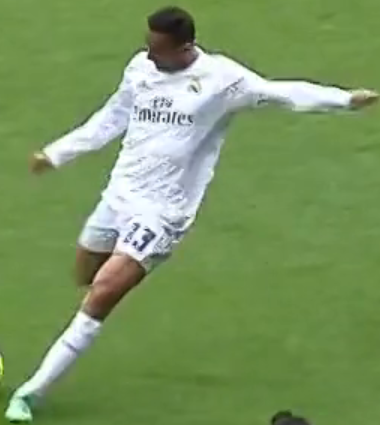

In [5]:
from PIL import Image
from IPython.display import display

img_path = "/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-03-05 - 18-00 Real Madrid 7 - 1 Celta Vigo/0/206941-7783-135782-20495-Player_team_left-13-0fbr000_001cd2cb0002-425x380.png"

img = Image.open(img_path)
display(img)

Bounding Box Crops

/data/manser/soccernet/reid/train/train/spain_laliga/2015-2016/2016-03-05 - 18-00 Real Madrid 7 - 1 Celta Vigo/0/206941-7783-135782-20495-Player_team_left-13-0fbr000_001cd2cb0002-425x380.png

In [6]:
import json
from pathlib import Path

path = Path("/data/manser/soccernet/reid/train/train/train_bbox_info.json")

with open(path) as f:
    data = json.load(f)

print(type(data))
print(len(data))

# erste Einträge anzeigen
for i, (k,v) in enumerate(data.items()):
    print(k)
    print(v)
    if i == 3:
        break

<class 'dict'>
248234
0
{'bbox_idx': 0, 'action_idx': 0, 'person_uid': 0, 'frame_idx': 0, 'clazz': 'Player_team_left', 'id': 'None', 'UAI': '000r000_004597cb000d', 'relative_path': 'england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley/0', 'height': 74, 'width': 32}
1
{'bbox_idx': 1, 'action_idx': 0, 'person_uid': 1, 'frame_idx': 0, 'clazz': 'Player_team_left', 'id': 'None', 'UAI': '000r000_004597cb000e', 'relative_path': 'england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley/0', 'height': 51, 'width': 20}
2
{'bbox_idx': 2, 'action_idx': 0, 'person_uid': 2, 'frame_idx': 0, 'clazz': 'Player_team_left', 'id': 'b', 'UAI': '000r000_004597cb000f', 'relative_path': 'england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley/0', 'height': 63, 'width': 24}
3
{'bbox_idx': 3, 'action_idx': 0, 'person_uid': 3, 'frame_idx': 0, 'clazz': 'Player_team_left', 'id': '2', 'UAI': '000r000_004597cb0010', 'relative_path': 'england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley

{
 'bbox_idx': 0,
 'action_idx': 0,
 'person_uid': 0,
 'frame_idx': 0,
 'clazz': 'Player_team_left',
 'id': 'None',
 'UAI': '000r000_004597cb000d',
 'relative_path': 'england_epl/.../0',
 'height': 74,
 'width': 32
}

In [7]:
from collections import Counter

uids = [v["person_uid"] for v in data.values()]
Counter(uids).most_common(10)

[(8607, 9),
 (37652, 9),
 (37653, 9),
 (42940, 9),
 (42942, 9),
 (73713, 9),
 (73716, 9),
 (84776, 9),
 (84785, 9),
 (88793, 9)]